In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import os

fund_master = pd.read_csv('../data/processed/fund_master_cleaned.csv')
nav_history = pd.read_csv('../data/processed/nav_history_cleaned.csv')
aum_by_fund_house = pd.read_csv('../data/processed/aum_by_fund_house_cleaned.csv')
monthly_sip_inflows = pd.read_csv('../data/processed/monthly_sip_inflows_cleaned.csv')
category_inflows = pd.read_csv('../data/processed/category_inflows_cleaned.csv')
industry_folio_count = pd.read_csv('../data/processed/industry_folio_count_cleaned.csv')
scheme_performance = pd.read_csv('../data/processed/scheme_performance_cleaned.csv')
investor_transactions = pd.read_csv('../data/processed/investor_transactions_cleaned.csv')
portfolio_holdings = pd.read_csv('../data/processed/portfolio_holdings_cleaned.csv')
benchmark_indices = pd.read_csv('../data/processed/benchmark_indices_cleaned.csv')

print("CSVs loaded")

CSVs loaded


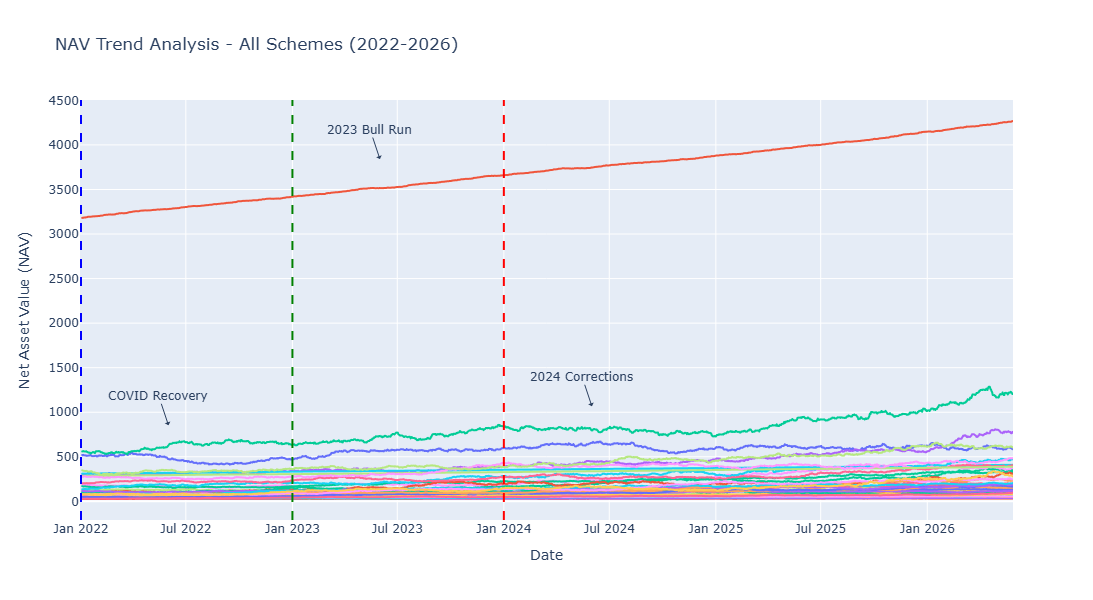

In [19]:
# NAV Trend Analysis [1]
# Plot daily NAV for all 40 schemes with annotations
nav_with_names = nav_history.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')
nav_with_names["date"] = pd.to_datetime(nav_with_names["date"])

fig = px.line(nav_with_names, 
              x='date', 
              y='nav', 
              color='scheme_name',
              title='NAV Trend Analysis - All Schemes (2022-2026)',
              labels={'date': 'Date', 'nav': 'Net Asset Value (NAV)', 'scheme_name': 'Fund Name'})

# Add vertical lines for key periods
fig.add_vline(x="2022-01-01", line_width=2, line_dash="dash", line_color="blue")
fig.add_vline(x="2023-01-01", line_width=2, line_dash="dash", line_color="green")
fig.add_vline(x="2024-01-01", line_width=2, line_dash="dash", line_color="red")

# Add annotations
fig.add_annotation(
    x="2022-06-01",
    y=nav_with_names["nav"].max() * 0.2,
    text="COVID Recovery",
    showarrow=True,
    arrowhead=1,
)

fig.add_annotation(
    x="2023-06-01",
    y=nav_with_names["nav"].max() * 0.90,
    text="2023 Bull Run",
    showarrow=True,
    arrowhead=1,
)

fig.add_annotation(
    x="2024-06-01",
    y=nav_with_names["nav"].max() * 0.25,
    text="2024 Corrections",
    showarrow=True,
    arrowhead=1,
)

fig.update_layout(height=600, width=1000, showlegend=False)
fig.write_image('../reports/figures/nav_trend_analysis.png')
fig.show()

In [3]:
kotak_liquid_check = nav_with_names[
    nav_with_names['scheme_name'] == 'Kotak Liquid Fund - Regular - Growth'
].copy()

kotak_liquid_check = kotak_liquid_check.sort_values('date')

print(kotak_liquid_check.tail())
print("Maximum NAV:", kotak_liquid_check['nav'].max())

       amfi_code       date        nav                           scheme_name
51451     120844 2026-05-25  4259.2727  Kotak Liquid Fund - Regular - Growth
51452     120844 2026-05-26  4262.3302  Kotak Liquid Fund - Regular - Growth
51453     120844 2026-05-27  4264.9256  Kotak Liquid Fund - Regular - Growth
51454     120844 2026-05-28  4266.9021  Kotak Liquid Fund - Regular - Growth
51455     120844 2026-05-29  4268.5497  Kotak Liquid Fund - Regular - Growth
Maximum NAV: 4268.5497


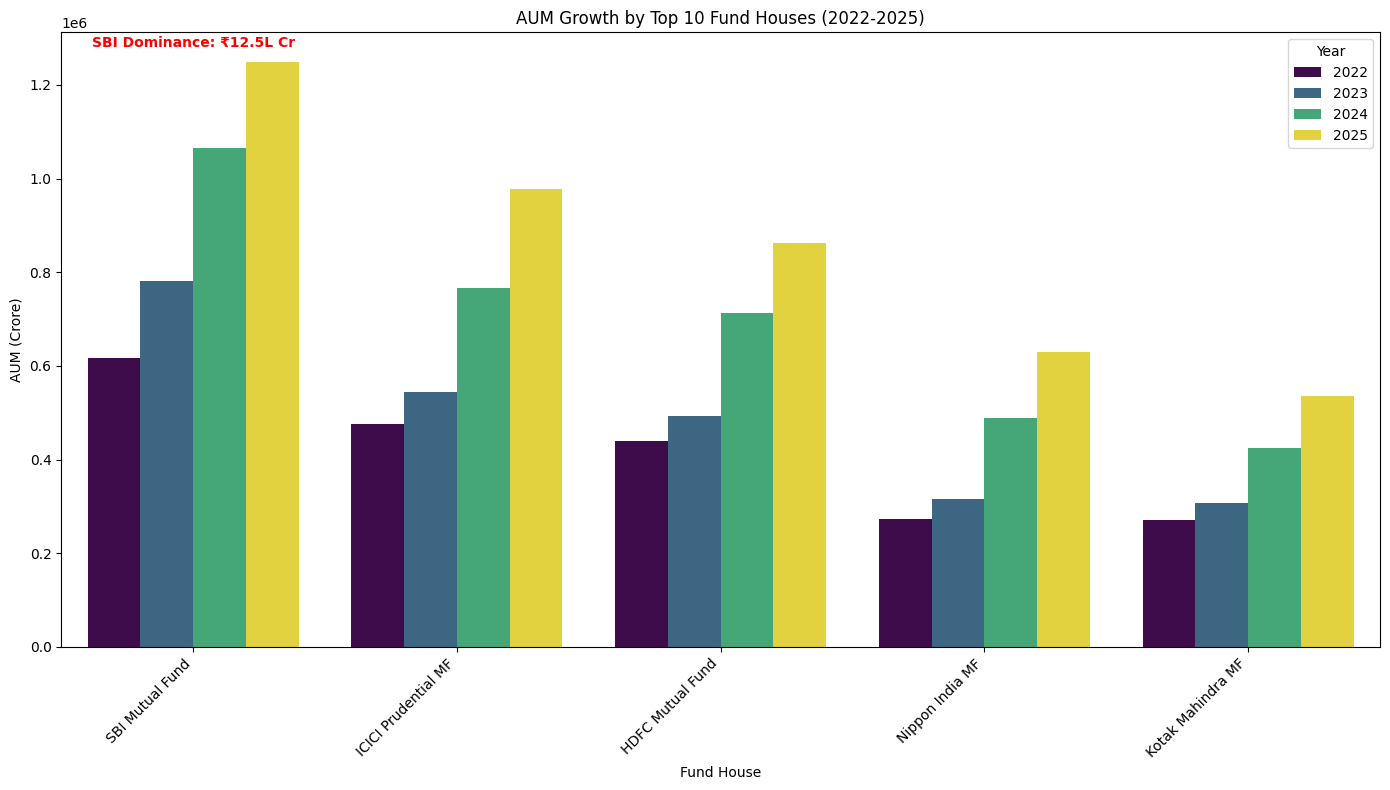

In [4]:
# AUM Growth - Grouped Bar Chart by Year [2]
import seaborn as sns
import matplotlib.pyplot as plt

# Extract year from date
aum_by_fund_house['year'] = pd.to_datetime(aum_by_fund_house['date']).dt.year

# Filter years 2022-2025
aum_years = aum_by_fund_house[aum_by_fund_house['year'].between(2022, 2025)]

# Get top 10 fund houses by latest year
latest_year = aum_years['year'].max()
top_funds = aum_years[aum_years['year'] == latest_year].nlargest(10, 'aum_crore')['fund_house'].tolist()
aum_top_years = aum_years[aum_years['fund_house'].isin(top_funds)]

# Create grouped bar chart
plt.figure(figsize=(14, 8))
sns.barplot(data=aum_top_years, 
            x='fund_house', 
            y='aum_crore', 
            hue='year', 
            palette='viridis',
            errorbar=None)

# Highlight SBI dominance
sbi_data = aum_top_years[aum_top_years['fund_house'] == 'SBI Mutual Fund']
if not sbi_data.empty:
    plt.text(x='SBI Mutual Fund', 
             y=sbi_data['aum_crore'].max() * 1.025,
             s="SBI Dominance: ₹12.5L Cr",
             ha='center', 
             color='red',
             fontweight='bold')

plt.title('AUM Growth by Top 10 Fund Houses (2022-2025)')
plt.xlabel('Fund House')
plt.ylabel('AUM (Crore)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('../reports/figures/aum_growth_grouped_bar.png', dpi=300, bbox_inches='tight')
plt.show()

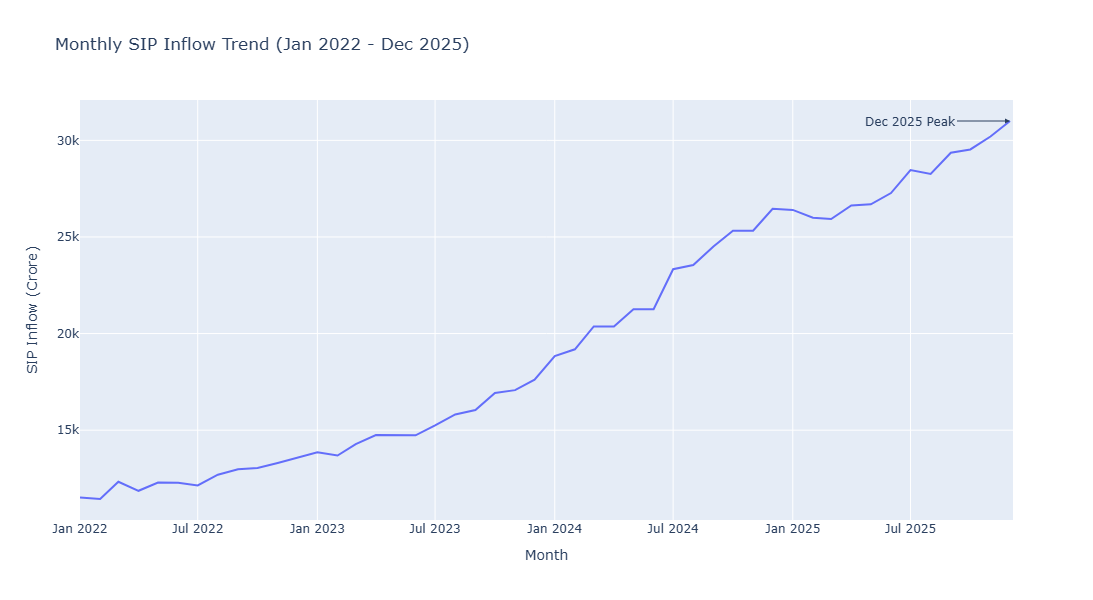

        month  sip_inflow_crore  active_sip_accounts_crore  \
47 2025-12-01             31002                       9.35   

    new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
47                    9.8                15.9           17.17  


In [5]:
# Monthly SIP Inflow Trend with December 2025 Highlight [3]

monthly_sip_inflows['month'] = pd.to_datetime(
    monthly_sip_inflows['month']
)

fig = px.line(monthly_sip_inflows, 
              x='month', 
              y='sip_inflow_crore',
              title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)',
              labels={'month': 'Month', 'sip_inflow_crore': 'SIP Inflow (Crore)'})

# Highlight December 2025 peak
dec_2025 = monthly_sip_inflows[
    monthly_sip_inflows['month'].dt.strftime('%Y-%m') == '2025-12'
]

if not dec_2025.empty:
    fig.add_annotation(
        x=dec_2025['month'].iloc[0].to_pydatetime(),
        y=dec_2025['sip_inflow_crore'].iloc[0],
        text="Dec 2025 Peak",
        showarrow=True,
        arrowhead=2,
        ax=-100,
        ay=0
    )

fig.update_layout(height=600, width=1000)
fig.write_image('../reports/figures/monthly_sip_inflow_trend.png')
fig.show()

print(dec_2025)

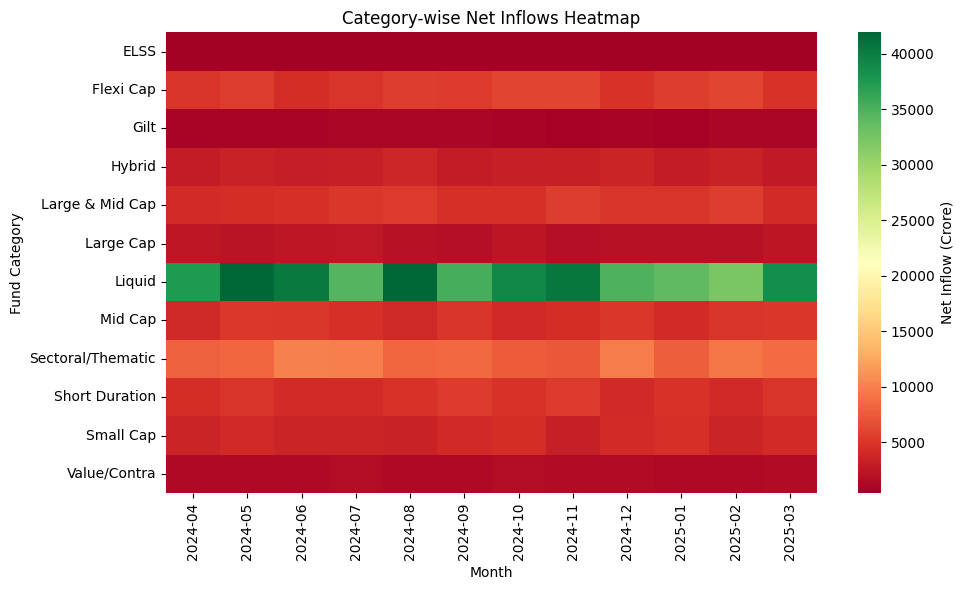

In [6]:
# Category-wise Net Inflows Heatmap [4]

import matplotlib.pyplot as plt
import seaborn as sns

# Convert month to datetime
category_inflows['month'] = pd.to_datetime(category_inflows['month'])
category_inflows['month_year'] = category_inflows['month'].dt.strftime('%Y-%m')

# Pivot data for heatmap
pivot_data = category_inflows.pivot(
    index='category',
    columns='month_year',
    values='net_inflow_crore'
)

# Create heatmap using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_data, 
            cmap='RdYlGn', 
            annot=False,
            cbar_kws={'label': 'Net Inflow (Crore)'})
plt.title('Category-wise Net Inflows Heatmap')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.tight_layout()
plt.savefig('../reports/figures/category_wise_net_inflows_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

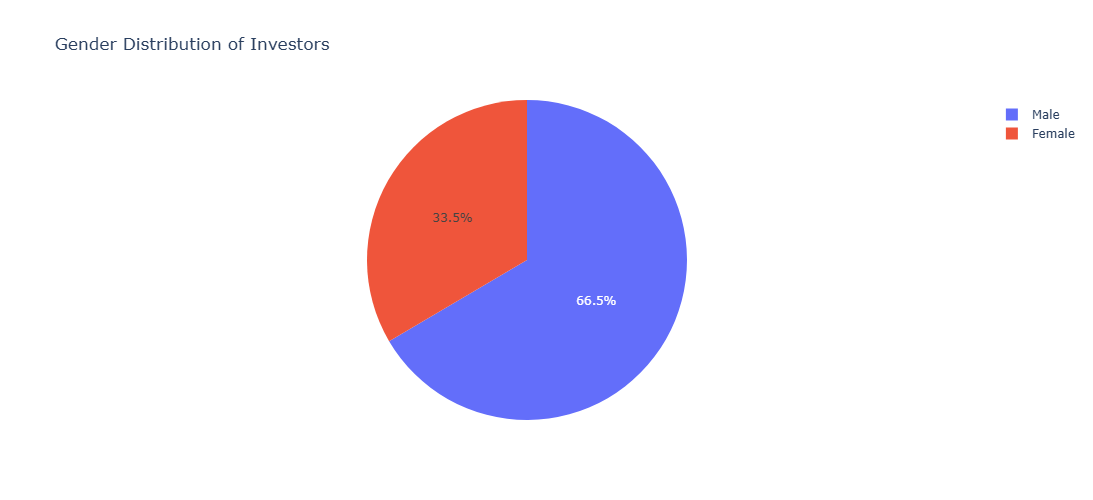

In [7]:
# Gender Distribution [5]
gender_counts = investor_transactions['gender'].value_counts().reset_index()
gender_counts.columns = ['Gender', 'Count']

fig = px.pie(gender_counts, 
             values='Count', 
             names='Gender',
             title='Gender Distribution of Investors')

fig.update_layout(width=500, height=500)
fig.write_image('../reports/figures/gender_distribution.png')
fig.show()

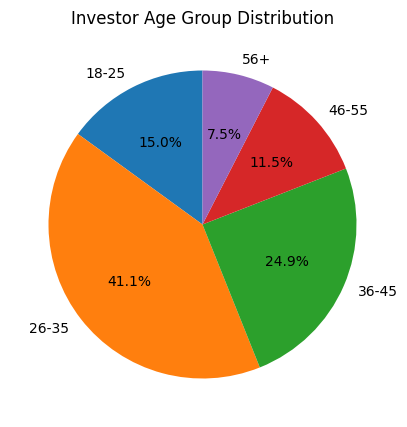

In [8]:
import matplotlib.pyplot as plt

# Age Group Distribution - Pie Chart [6]
age_counts = investor_transactions['age_group'].value_counts()
age_order = ['18-25', '26-35', '36-45', '46-55', '56+']
age_counts = age_counts.reindex(age_order)

plt.figure(figsize=(5, 5))
plt.pie(age_counts, 
        labels=age_counts.index, 
        autopct='%1.1f%%',
        startangle=90)
plt.title('Investor Age Group Distribution')
plt.savefig('../reports/figures/age_group_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

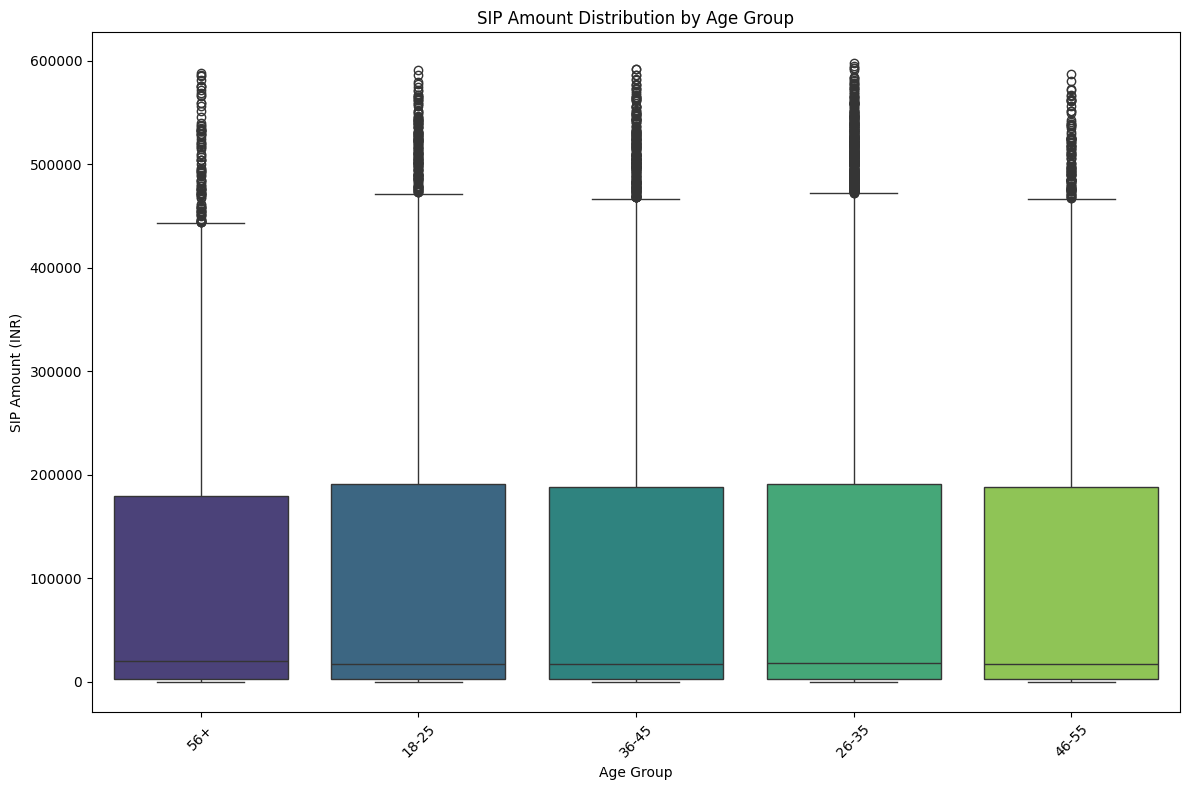

In [9]:
# SIP Amount Distribution by Age Group - Box Plot [7]
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=investor_transactions,
    x='age_group',
    y='amount_inr',
    hue='age_group',
    palette='viridis',
    legend=False
)

plt.title('SIP Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (INR)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    '../reports/figures/sip_amount_by_age_boxplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

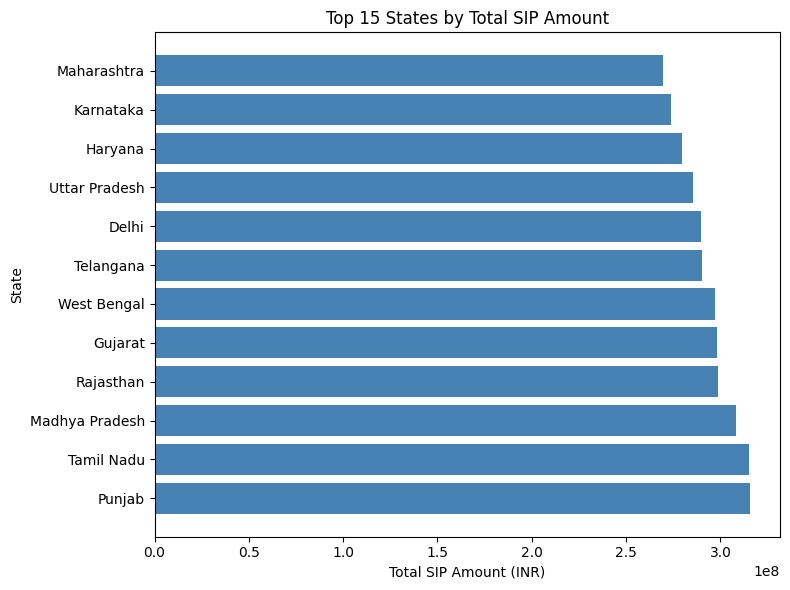

In [10]:
# State-wise SIP Amount - Horizontal Bar Chart (Matplotlib) [8]
import matplotlib.pyplot as plt

state_investment = investor_transactions.groupby('state')['amount_inr'].sum().reset_index()
state_investment = state_investment.nlargest(15, 'amount_inr')

plt.figure(figsize=(8, 6))
plt.barh(state_investment['state'], state_investment['amount_inr'], color='steelblue')
plt.title('Top 15 States by Total SIP Amount')
plt.xlabel('Total SIP Amount (INR)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('../reports/figures/state_wise_sip_amount.png', dpi=300, bbox_inches='tight')
plt.show()


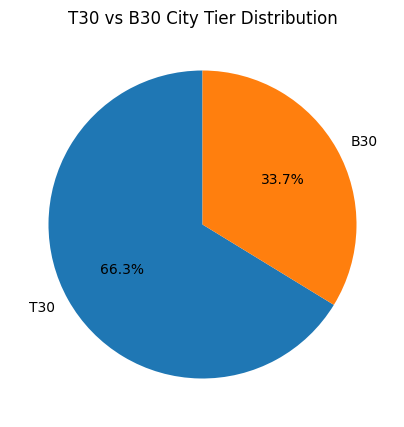

In [11]:
# T30 vs B30 City Tier Distribution - Pie Chart (Matplotlib) [9]
import matplotlib.pyplot as plt

city_counts = investor_transactions['city_tier'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(city_counts, 
        labels=city_counts.index, 
        autopct='%1.1f%%',
        startangle=90)
plt.title('T30 vs B30 City Tier Distribution')
plt.savefig('../reports/figures/city_tier_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

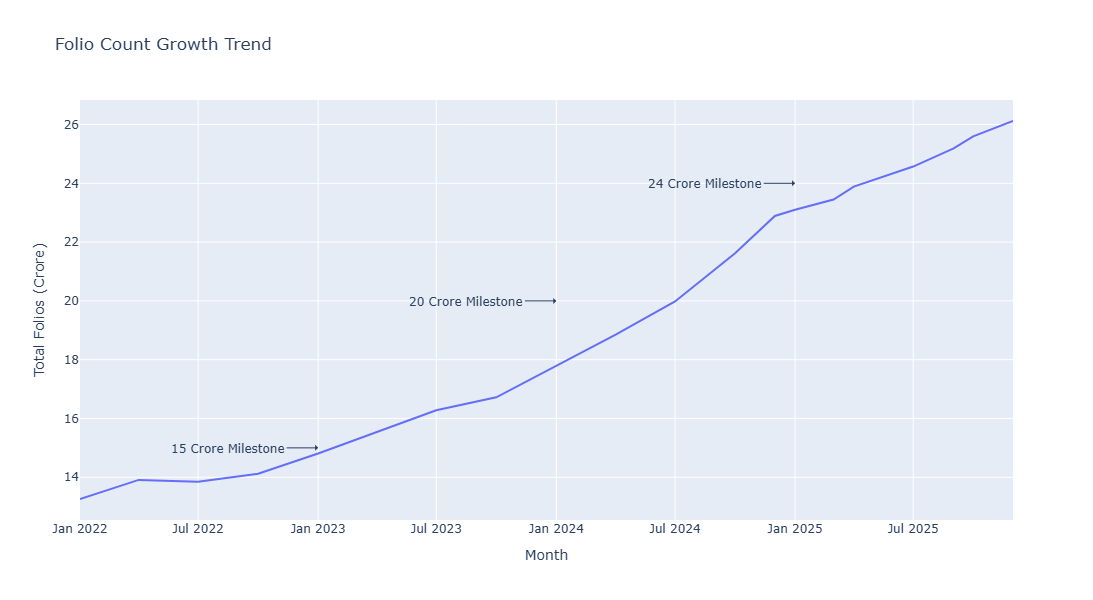

2022-01-01
2025-12-01


In [12]:
# Folio Count Growth [10]

fig = px.line(industry_folio_count, 
              x='month', 
              y='total_folios_crore',
              title='Folio Count Growth Trend',
              labels={'month': 'Month', 'total_folios_crore': 'Total Folios (Crore)'})

# Add milestone annotations
milestones = [
    ('2023-01-01', 15, '15 Crore Milestone'),
    ('2024-01-01', 20, '20 Crore Milestone'),
    ('2025-01-01', 24, '24 Crore Milestone')
]

for date, y_val, text in milestones:
    fig.add_annotation(
        x=date,
        y=y_val,
        ax=-90,
        ay=0,
        text=text,
        showarrow=True,
        arrowhead=1
    )

fig.update_layout(height=600, width=1000)
fig.write_image('../reports/figures/folio_count_growth.png')
fig.show()
print(industry_folio_count['month'].min())
print(industry_folio_count['month'].max())

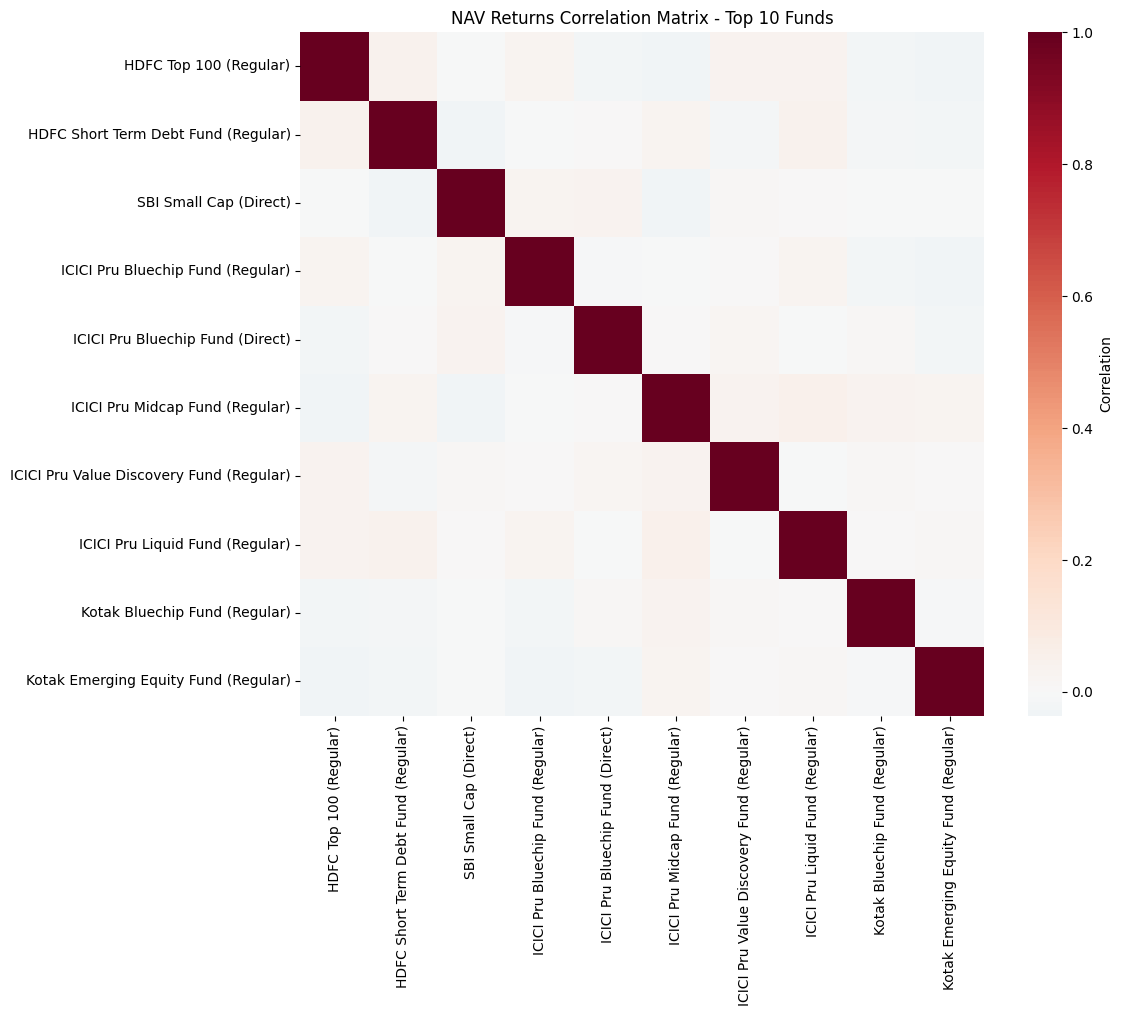

In [13]:
# Correlation Matrix [11]

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select 10 funds with most NAV data
top_10_funds = nav_history['amfi_code'].value_counts().head(10).index.tolist()

# Calculate daily returns for each fund
nav_pivot = nav_history[nav_history['amfi_code'].isin(top_10_funds)].pivot(
    index='date', 
    columns='amfi_code', 
    values='nav'
)

# Calculate daily returns
returns_pct = nav_pivot.pct_change().dropna()

# Get fund names for labels
fund_master['display_name'] = (
    fund_master['scheme_name']
    .str.replace(' Fund - Regular Plan - Growth', ' (Regular)', regex=False)
    .str.replace(' Fund - Direct Plan - Growth', ' (Direct)', regex=False)
    .str.replace(' - Regular - Growth', ' (Regular)', regex=False)
    .str.replace(' - Direct - Growth', ' (Direct)', regex=False)
)
fund_master_dict = dict(zip(fund_master['amfi_code'], fund_master['display_name']))
returns_pct.columns = [fund_master_dict.get(col, col) for col in returns_pct.columns]

# Calculate correlation matrix
correlation_matrix = returns_pct.corr()

# Create heatmap using seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=False, 
            cmap='RdBu_r',
            center=0,
            square=True,
            cbar_kws={'label': 'Correlation'})
plt.title('NAV Returns Correlation Matrix - Top 10 Funds')
plt.tight_layout()
plt.savefig('../reports/figures/nav_return_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

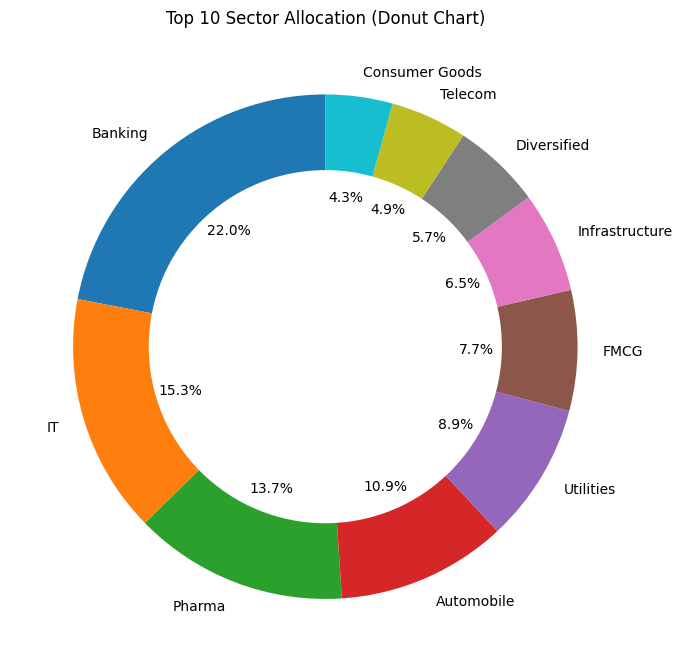

In [14]:
# Sector Allocation - Donut Chart (Matplotlib) [12]

import matplotlib.pyplot as plt

# Group by sector and sum weights
sector_weights = portfolio_holdings.groupby('sector')['weight_pct'].sum().reset_index()
sector_weights = sector_weights.nlargest(10, 'weight_pct')

plt.figure(figsize=(7,7))
plt.pie(sector_weights['weight_pct'], 
        labels=sector_weights['sector'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.4))  

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Top 10 Sector Allocation (Donut Chart)')
plt.tight_layout()
plt.savefig('../reports/figures/sector_allocation_donut.png', dpi=300, bbox_inches='tight')
plt.show()

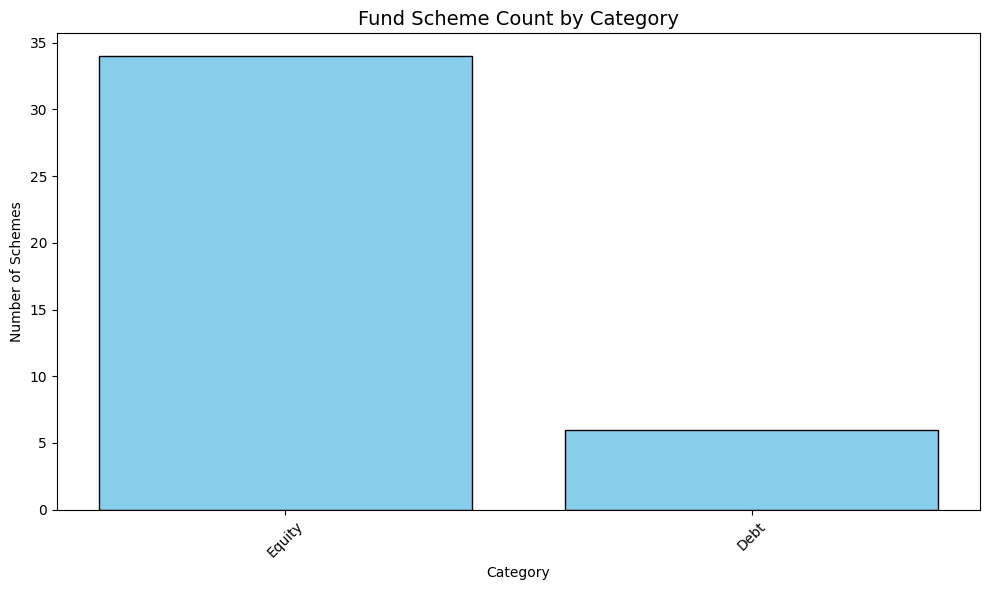

Scheme count by category:
  Category  Count
0   Equity     34
1     Debt      6


In [15]:
# Count schemes by category [13]
category_counts = fund_master['category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

# Sort for better visualization
category_counts = category_counts.sort_values('Count', ascending=False)

# Create bar chart using matplotlib
plt.figure(figsize=(10, 6))
plt.bar(category_counts['Category'], category_counts['Count'], color='skyblue', edgecolor='black')
plt.title('Fund Scheme Count by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Number of Schemes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/scheme_count_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

print("Scheme count by category:")
print(category_counts)

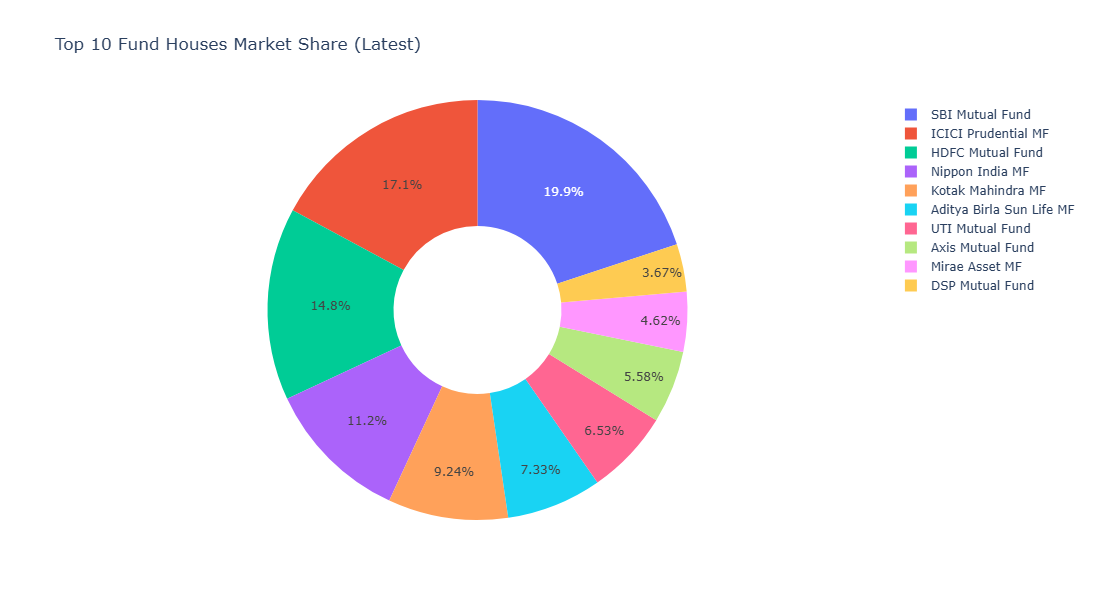

In [16]:
# Fund House Market Share [14]

# Get latest AUM data
latest_aum = aum_by_fund_house[aum_by_fund_house['date'] == aum_by_fund_house['date'].max()]
top_10_aum = latest_aum.nlargest(10, 'aum_crore')

# Create donut chart
fig = px.pie(top_10_aum, 
             values='aum_crore', 
             names='fund_house',
             title='Top 10 Fund Houses Market Share (Latest)',
             hole=0.4)

fig.update_layout(height=600, width=800)
fig.write_image('../reports/figures/fund_house_market_share.png')
fig.show()

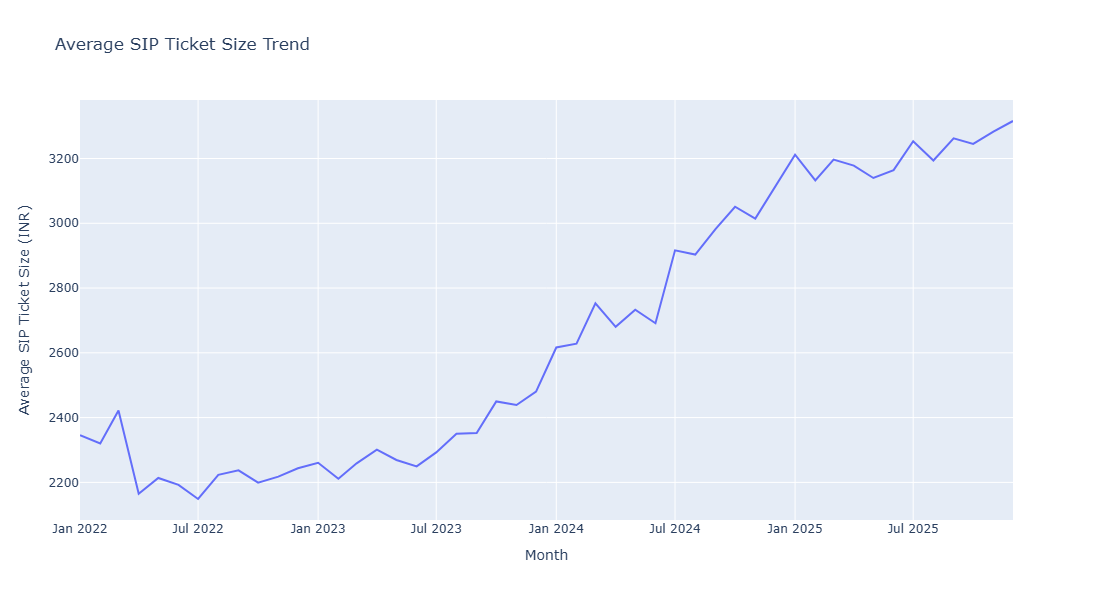

In [17]:
# Average SIP Ticket Size Trend [15]

# Calculate average SIP ticket size
monthly_sip_inflows['avg_sip_ticket'] = (
    monthly_sip_inflows['sip_inflow_crore'] * 10000000 /  # Convert crore to INR
    (monthly_sip_inflows['active_sip_accounts_crore'] * 10000000)  # Convert crore to actual accounts
)

fig = px.line(monthly_sip_inflows, 
              x='month', 
              y='avg_sip_ticket',
              title='Average SIP Ticket Size Trend',
              labels={'month': 'Month', 'avg_sip_ticket': 'Average SIP Ticket Size (INR)'})

fig.update_layout(height=600, width=1000)
fig.write_image('../reports/figures/avg_sip_ticket_trend.png')
fig.show()

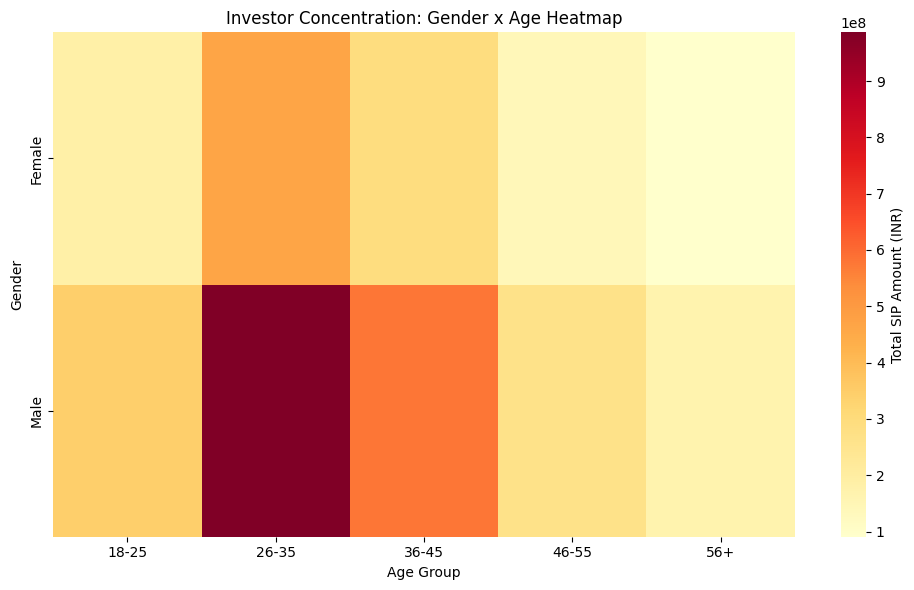

In [18]:
# Investor Concentration: Gender x Age Heatmap [16]

import seaborn as sns
import matplotlib.pyplot as plt

# Create cross-tabulation
gender_age_pivot = pd.crosstab(
    investor_transactions['gender'], 
    investor_transactions['age_group'],
    values=investor_transactions['amount_inr'],
    aggfunc='sum'
)

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(gender_age_pivot, 
            cmap='YlOrRd',
            cbar_kws={'label': 'Total SIP Amount (INR)'})
plt.title('Investor Concentration: Gender x Age Heatmap')
plt.xlabel('Age Group')
plt.ylabel('Gender')
plt.tight_layout()
plt.savefig('../reports/figures/gender_age_concentration_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()